# Regional biases: CESM3 / MOM6 experiment comparison

Regional bias diagnostics for a set of coupled and forced experiments,
complementing the global views in `biases.ipynb` and `key_diagnostics.ipynb`.
The shared `Experiment` class lives in `experiment.py` so it can be reused
across notebooks.

**Experiments compared**

| name | mode | data folder |
|------|------|-------------|
| `CTRL` | coupled | `data/coupled_55years` |
| `coupled_bANN_1.0` | coupled | `data/coupled_55years` |
| `coupled_bANN_1.0_uANN_1.0` | coupled | `data/coupled_55years` |
| `forced_CTRL` | forced | `data/forced_55years` |
| `forced_bANN_1.0` | forced | `data/forced_55years` |
| `forced_bANN_1.0_uANN_1.0` | forced | `data/forced_55years` |

**Kernel:** `env-from-npl-2024a` (Python 3.11.6).

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import os

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cftime

from experiment import Experiment

plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams.update({'font.size': 18})

# Repo-root-relative paths (this notebook lives in <repo>/notebooks)
REPO = os.path.abspath(os.path.join(os.getcwd(), '..'))
YAML_DIR = os.path.join(REPO, 'yamls')
COUPLED_DIR = os.path.join(REPO, 'data', 'coupled_55years')
FORCED_DIR = os.path.join(REPO, 'data', 'forced_55years')
FIG_DIR = os.path.join(REPO, 'figures', 'coupled_55years')

print('REPO       =', REPO)
print('YAML_DIR   =', YAML_DIR)
print('COUPLED_DIR=', COUPLED_DIR)
print('FORCED_DIR =', FORCED_DIR)

REPO       = /glade/u/home/pavelp/m2lines-CESM3-diagnostics
YAML_DIR   = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/yamls
COUPLED_DIR= /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/coupled_55years
FORCED_DIR = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/forced_55years


## Initialize experiments (read-only)

Each experiment is defined by its `name`, the diagnostics YAML config, and the
folder holding its postprocessed NetCDF files. Initialization is read-only: it
only reads config + (best-effort) grid, and never triggers heavy computation.

In [2]:
# (name, folder) for each experiment. YAML config is yamls/<name>.yaml
experiment_defs = [
    ('CTRL',                        COUPLED_DIR),
    ('coupled_bANN_1.0',            COUPLED_DIR),
    ('coupled_bANN_1.0_uANN_1.0',   COUPLED_DIR),
    ('forced_CTRL',                 FORCED_DIR),
    ('forced_bANN_1.0',             FORCED_DIR),
    ('forced_bANN_1.0_uANN_1.0',    FORCED_DIR),
]

exps = {}
for name, folder in experiment_defs:
    yaml_path = os.path.join(YAML_DIR, f'{name}.yaml')
    exps[name] = Experiment(yaml_path, folder=folder, name=name,
                            load_grid=True, verbose=True)

exp_names = list(exps.keys())
coupled_names = ['coupled_bANN_1.0', 'coupled_bANN_1.0_uANN_1.0', 'CTRL' ]
forced_names = ['forced_bANN_1.0', 'forced_bANN_1.0_uANN_1.0', 'forced_CTRL']

print('\nInitialized:', exp_names)

[CTRL] casename=CTRL, rundir=/glade/derecho/scratch/jiarongw/CTRL/run


ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/pavelp/conda-envs/env-from-npl-2024a/share/proj failed


MOM6 grid successfully loaded... 

[coupled_bANN_1.0] casename=coupled_bANN_1.0, rundir=/glade/derecho/scratch/pavelp/coupled_bANN_1.0/run
MOM6 grid successfully loaded... 

[coupled_bANN_1.0_uANN_1.0] casename=coupled_bANN_1.0_uANN_1.0, rundir=/glade/derecho/scratch/pavelp/coupled_bANN_1.0_uANN_1.0/run
MOM6 grid successfully loaded... 

[forced_CTRL] casename=forced_CTRL, rundir=/glade/derecho/scratch/pavelp/forced_CTRL/run
MOM6 grid successfully loaded... 

[forced_bANN_1.0] casename=forced_bANN_1.0, rundir=/glade/derecho/scratch/pavelp/forced_bANN_1.0/run
MOM6 grid successfully loaded... 

[forced_bANN_1.0_uANN_1.0] casename=forced_bANN_1.0_uANN_1.0, rundir=/glade/derecho/scratch/pavelp/forced_bANN_1.0_uANN_1.0/run
MOM6 grid successfully loaded... 


Initialized: ['CTRL', 'coupled_bANN_1.0', 'coupled_bANN_1.0_uANN_1.0', 'forced_CTRL', 'forced_bANN_1.0', 'forced_bANN_1.0_uANN_1.0']


In [3]:
# Short legend labels (regime is shown in the panel title, so it is omitted here)
LABELS = {
    'CTRL':                       'GM',
    'coupled_bANN_1.0':           'bANN',
    'coupled_bANN_1.0_uANN_1.0':  'bANN_uANN',
    'forced_CTRL':                'GM',
    'forced_bANN_1.0':            'bANN',
    'forced_bANN_1.0_uANN_1.0':   'bANN_uANN',
}

# 1. Analysis regions

A set of rectangular lon/lat boxes used for the regional diagnostics below
(longitudes in the 0-360$^\circ$ convention):

| Region | Latitude | Longitude |
|---|---|---|
| Global | everything | everything |
| Southern Ocean | 30$^\circ$S - 60$^\circ$S | all |
| Agulhas | 30$^\circ$S - 60$^\circ$S | 0$^\circ$E - 60$^\circ$E |
| Malvinas | 30$^\circ$S - 60$^\circ$S | 60$^\circ$W - 0$^\circ$ |
| Kuroshio | 20$^\circ$N - 50$^\circ$N | 120$^\circ$E - 180$^\circ$E |
| Gulf Stream | 30$^\circ$N - 60$^\circ$N | 80$^\circ$W - 20$^\circ$W |
| Tropical Pacific | 30$^\circ$S - 30$^\circ$N | 130$^\circ$E - 290$^\circ$E |

The map shows the surface temperature bias (model $-$ WOA18) for the GM coupled
control, with each region outlined.

In [4]:
%matplotlib inline
import matplotlib as mpl

# Rectangular analysis regions as (lat_south, lat_north, lon_west, lon_east).
# Longitudes are in the 0-360 convention. 'Global' (None) means the whole domain.
REGIONS = {
    'Global':           None,
    'Southern Ocean':   (-60, -30,   0, 360),
    'Agulhas':          (-60, -30,   0,  60),
    'Malvinas':         (-60, -30, 300, 360),
    'Kuroshio':         ( 20,  50, 120, 180),
    'Gulf Stream':      ( 30,  60, 280, 340),
    'Tropical Pacific': (-30,  30, 130, 290),
}

REGION_COLORS = {
    'Southern Ocean':   'k',
    'Agulhas':          'tab:green',
    'Malvinas':         'tab:purple',
    'Kuroshio':         'tab:orange',
    'Gulf Stream':      'tab:red',
    'Tropical Pacific': 'tab:cyan',
}

def region_mask(exp, region):
    """Boolean DataArray (yh, xh) selecting grid cells inside `region`."""
    lat = exp.grd.geolat
    lon360 = exp.grd.geolon % 360.0
    if REGIONS[region] is None:                 # Global -> everything
        return xr.ones_like(lat, dtype=bool)
    s, n, w, e = REGIONS[region]
    return (lat >= s) & (lat <= n) & (lon360 >= w) & (lon360 <= e)

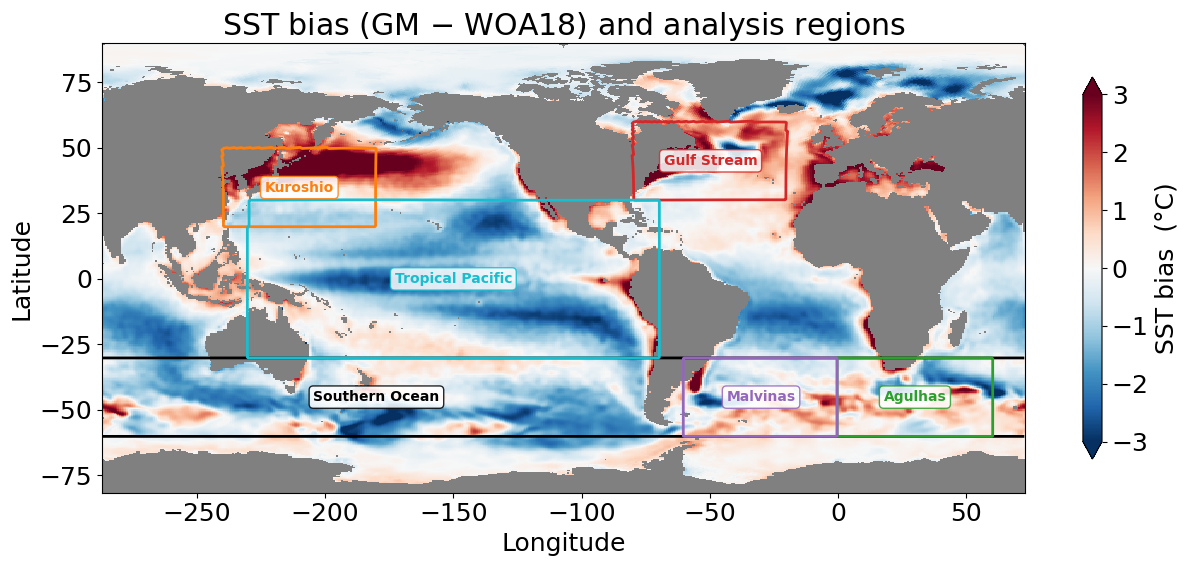

In [5]:
# Surface temperature (SST) bias (model - WOA18) for the GM coupled control ('CTRL'),
# with every analysis region outlined. 'Global' covers the whole domain and is not drawn.
exp = exps['CTRL']

sst_bias = exp.thetao().thetao_bias.isel(z_l=0)   # (yh, xh), degC

# pcolormesh needs finite X/Y; fill NaN land points in the coords (as in biases.ipynb).
ydim, xdim = exp.grd.geolon.dims
lon = exp.grd.geolon.ffill(xdim).bfill(xdim).ffill(ydim).bfill(ydim).values
lat = exp.grd.geolat.ffill(ydim).bfill(ydim).ffill(xdim).bfill(xdim).values

fig, ax = plt.subplots(figsize=(13, 6))
ax.set_facecolor('gray')
norm = mpl.colors.Normalize(vmin=-3, vmax=3)
pc = ax.pcolormesh(lon, lat, np.ma.masked_invalid(sst_bias.values),
                   cmap='RdBu_r', norm=norm, shading='auto')
cb = fig.colorbar(pc, ax=ax, shrink=0.85, extend='both')
cb.set_label('SST bias  (\u00b0C)')

# Outline each region and label it at the box centre.
for name, box in REGIONS.items():
    if box is None:                       # 'Global' = whole domain
        continue
    m = region_mask(exp, name).values.astype(float)
    ax.contour(lon, lat, m, levels=[0.5],
               colors=REGION_COLORS[name], linewidths=2.0)
    s, n, w, e = box
    latc, lonc = 0.5 * (s + n), 0.5 * (w + e)
    d = (np.abs(exp.grd.geolat.values - latc)
         + np.abs((exp.grd.geolon.values % 360.0) - lonc))
    j, i = np.unravel_index(np.nanargmin(d), d.shape)
    ax.text(exp.grd.geolon.values[j, i], exp.grd.geolat.values[j, i], name,
            color=REGION_COLORS[name], fontsize=10, fontweight='bold',
            ha='center', va='center',
            bbox=dict(boxstyle='round', fc='white', ec=REGION_COLORS[name], alpha=0.85))

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('SST bias (GM $-$ WOA18) and analysis regions')
plt.tight_layout()
plt.show()

# 2. SST bias RMSE by region

Area-weighted root-mean-square SST bias (model $-$ WOA18) computed over each
region for all six experiments. Results are shown as a table and as grouped bar
charts (coupled / forced), with one group per region and one bar per experiment.

Area-weighted SST bias RMSE (degC):


,CTRL,coupled_bANN_1.0,coupled_bANN_1.0_uANN_1.0,forced_CTRL,forced_bANN_1.0,forced_bANN_1.0_uANN_1.0
Global,1.314,1.350,1.250,0.706,0.755,0.741
Southern Ocean,1.153,1.114,1.081,0.946,0.984,0.963
Agulhas,1.074,1.234,1.202,1.009,1.042,1.042
Malvinas,1.039,1.415,1.440,1.293,1.392,1.355
Kuroshio,2.385,2.488,2.504,1.190,1.507,1.498
Gulf Stream,2.123,2.647,2.459,1.695,1.862,1.777
Tropical Pacific,1.305,1.302,1.157,0.329,0.307,0.310


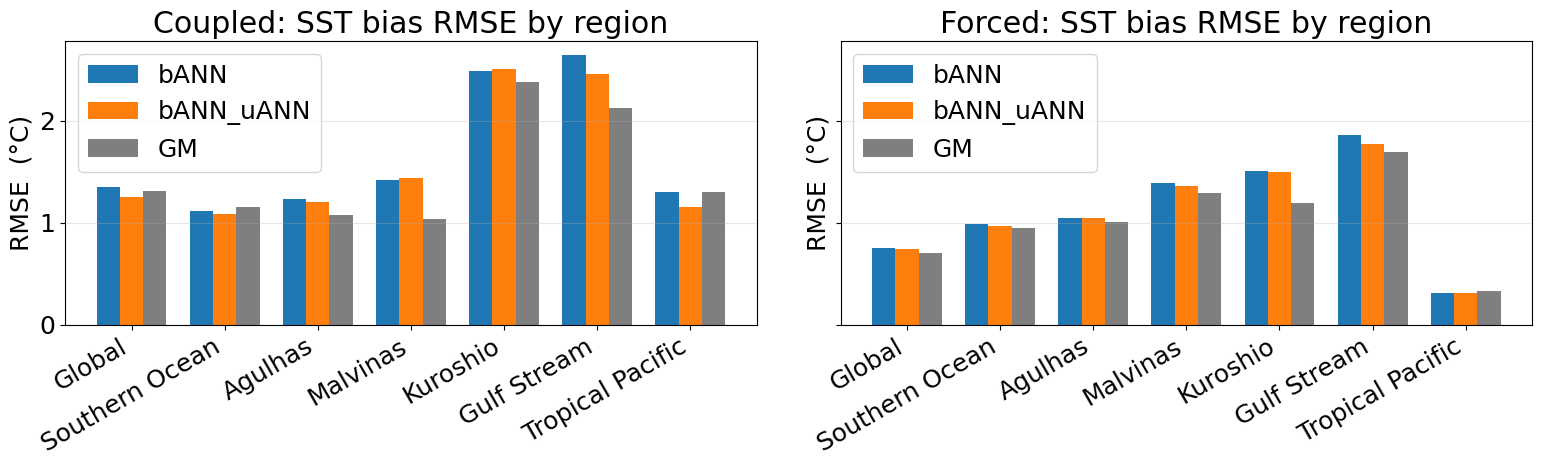

In [7]:
import pandas as pd


def region_sst_rmse(exp, region):
    """Area-weighted RMSE of surface thetao_bias over `region` [degC]."""
    bias = exp.thetao().thetao_bias.isel(z_l=0)          # (yh, xh)
    m = region_mask(exp, region) & np.isfinite(bias)
    w = exp.area.where(m)
    return float(np.sqrt((w * bias ** 2).sum() / w.sum()))


# RMSE table: rows = regions, columns = experiments.
region_names = list(REGIONS.keys())
rmse = pd.DataFrame(
    {name: [region_sst_rmse(exps[name], r) for r in region_names]
     for name in exp_names},
    index=region_names,
)
print('Area-weighted SST bias RMSE (degC):')
display(rmse.round(3))

# --- Grouped bar charts: one panel per regime, groups = regions, bars = experiments ---
bar_colors = {'GM': 'tab:gray', 'bANN': 'tab:blue', 'bANN_uANN': 'tab:orange'}
x = np.arange(len(region_names))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, names, regime in zip(axes,
                             [coupled_names, forced_names],
                             ['Coupled', 'Forced']):
    for k, name in enumerate(names):
        vals = rmse[name].values
        lbl = LABELS[name]
        ax.bar(x + (k - 1) * width, vals, width,
               label=lbl, color=bar_colors.get(lbl, None))
    ax.set_title(f'{regime}: SST bias RMSE by region')
    ax.set_xticks(x)
    ax.set_xticklabels(region_names, rotation=30, ha='right')
    ax.set_ylabel('RMSE  (\u00b0C)')
    ax.grid(axis='y', alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# 3. Sea-surface salinity bias and regions

The same analysis regions overlaid on the surface salinity bias (model $-$
WOA18) for the GM coupled control.

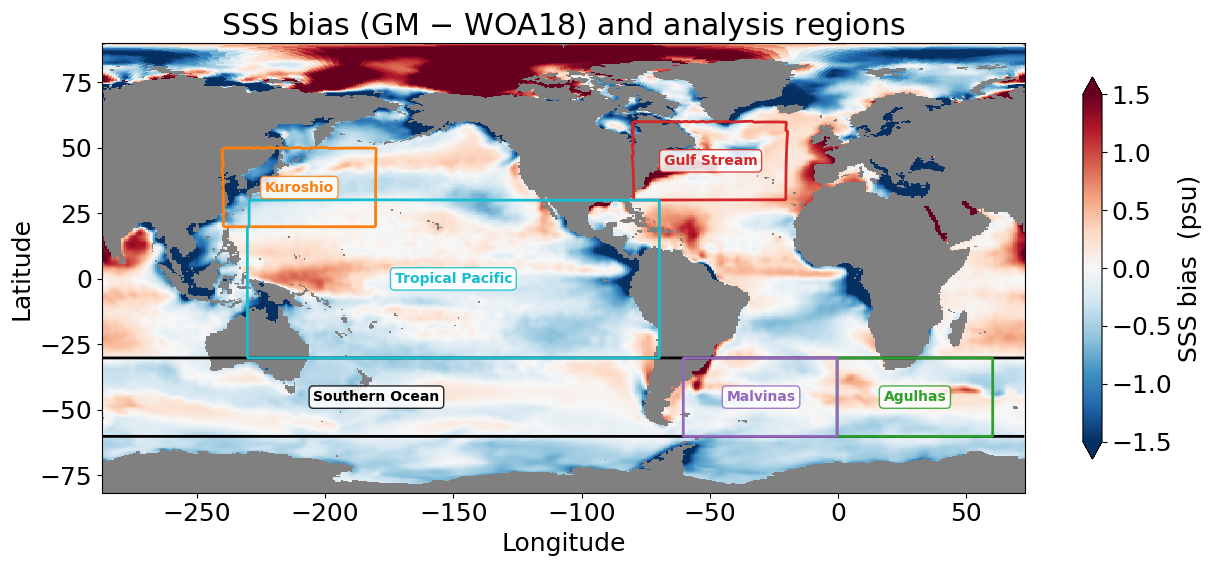

In [8]:
# Sea-surface salinity (SSS) bias (model - WOA18) for the GM coupled control ('CTRL'),
# with every analysis region outlined. 'Global' covers the whole domain and is not drawn.
exp = exps['CTRL']

sss_bias = exp.so().so_bias.isel(z_l=0)   # (yh, xh), psu

# pcolormesh needs finite X/Y; fill NaN land points in the coords (as in biases.ipynb).
ydim, xdim = exp.grd.geolon.dims
lon = exp.grd.geolon.ffill(xdim).bfill(xdim).ffill(ydim).bfill(ydim).values
lat = exp.grd.geolat.ffill(ydim).bfill(ydim).ffill(xdim).bfill(xdim).values

fig, ax = plt.subplots(figsize=(13, 6))
ax.set_facecolor('gray')
norm = mpl.colors.Normalize(vmin=-1.5, vmax=1.5)
pc = ax.pcolormesh(lon, lat, np.ma.masked_invalid(sss_bias.values),
                   cmap='RdBu_r', norm=norm, shading='auto')
cb = fig.colorbar(pc, ax=ax, shrink=0.85, extend='both')
cb.set_label('SSS bias  (psu)')

# Outline each region and label it at the box centre.
for name, box in REGIONS.items():
    if box is None:                       # 'Global' = whole domain
        continue
    m = region_mask(exp, name).values.astype(float)
    ax.contour(lon, lat, m, levels=[0.5],
               colors=REGION_COLORS[name], linewidths=2.0)
    s, n, w, e = box
    latc, lonc = 0.5 * (s + n), 0.5 * (w + e)
    d = (np.abs(exp.grd.geolat.values - latc)
         + np.abs((exp.grd.geolon.values % 360.0) - lonc))
    j, i = np.unravel_index(np.nanargmin(d), d.shape)
    ax.text(exp.grd.geolon.values[j, i], exp.grd.geolat.values[j, i], name,
            color=REGION_COLORS[name], fontsize=10, fontweight='bold',
            ha='center', va='center',
            bbox=dict(boxstyle='round', fc='white', ec=REGION_COLORS[name], alpha=0.85))

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('SSS bias (GM $-$ WOA18) and analysis regions')
plt.tight_layout()
plt.show()

# 4. SSS bias RMSE by region

Area-weighted root-mean-square surface salinity bias (model $-$ WOA18) over each
region for all six experiments, as a table and grouped bar charts
(coupled / forced).

Area-weighted SSS bias RMSE (psu):


,CTRL,coupled_bANN_1.0,coupled_bANN_1.0_uANN_1.0,forced_CTRL,forced_bANN_1.0,forced_bANN_1.0_uANN_1.0
Global,0.878,0.864,0.866,0.386,0.396,0.392
Southern Ocean,0.281,0.304,0.302,0.199,0.215,0.206
Agulhas,0.281,0.335,0.324,0.182,0.213,0.205
Malvinas,0.377,0.432,0.427,0.300,0.341,0.327
Kuroshio,1.134,1.080,1.034,0.208,0.272,0.271
Gulf Stream,0.784,1.009,1.052,0.629,0.672,0.654
Tropical Pacific,0.514,0.530,0.546,0.178,0.185,0.183


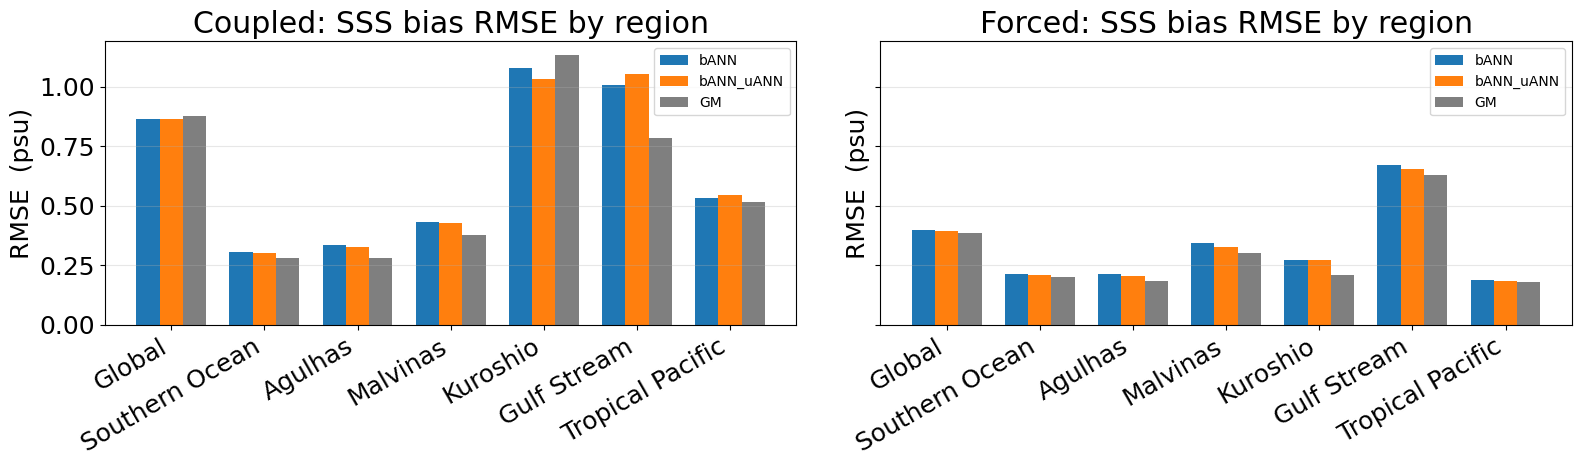

In [16]:
def region_sss_rmse(exp, region):
    """Area-weighted RMSE of surface so_bias over `region` [psu]."""
    bias = exp.so().so_bias.isel(z_l=0)                  # (yh, xh)
    m = region_mask(exp, region) & np.isfinite(bias)
    w = exp.area.where(m)
    return float(np.sqrt((w * bias ** 2).sum() / w.sum()))


# RMSE table: rows = regions, columns = experiments.
rmse_sss = pd.DataFrame(
    {name: [region_sss_rmse(exps[name], r) for r in region_names]
     for name in exp_names},
    index=region_names,
)
print('Area-weighted SSS bias RMSE (psu):')
display(rmse_sss.round(3))

# --- Grouped bar charts: one panel per regime, groups = regions, bars = experiments ---
x = np.arange(len(region_names))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, names, regime in zip(axes,
                             [coupled_names, forced_names],
                             ['Coupled', 'Forced']):
    for k, name in enumerate(names):
        vals = rmse_sss[name].values
        lbl = LABELS[name]
        ax.bar(x + (k - 1) * width, vals, width,
               label=lbl, color=bar_colors.get(lbl, None))
    ax.set_title(f'{regime}: SSS bias RMSE by region')
    ax.set_xticks(x)
    ax.set_xticklabels(region_names, rotation=30, ha='right')
    ax.set_ylabel('RMSE  (psu)')
    ax.grid(axis='y', alpha=0.3)
    ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

# 5. Temperature bias at 250 m and regions

The analysis regions overlaid on the temperature bias (model $-$ WOA18) at the
model level nearest 250 m, for the GM coupled control.

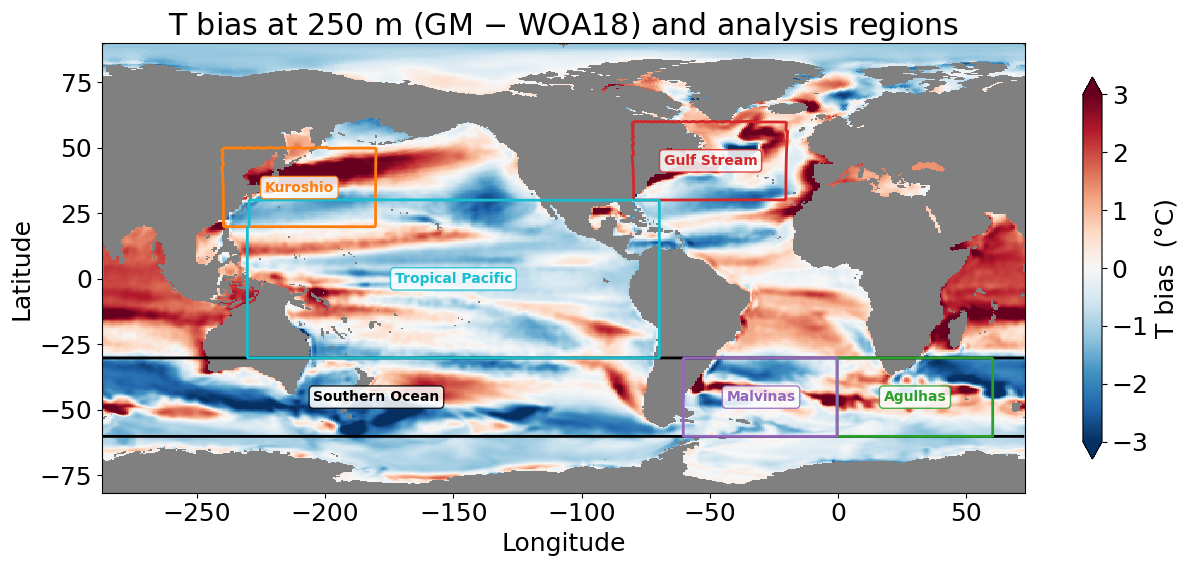

In [17]:
# Temperature bias (model - WOA18) at ~250 m for the GM coupled control ('CTRL'),
# with every analysis region outlined. 'Global' covers the whole domain and is not drawn.
exp = exps['CTRL']
TARGET_DEPTH = 250.0

t_bias = exp.thetao().thetao_bias.sel(z_l=TARGET_DEPTH, method='nearest')   # (yh, xh), degC
depth_used = float(t_bias.z_l)

# pcolormesh needs finite X/Y; fill NaN land points in the coords (as in biases.ipynb).
ydim, xdim = exp.grd.geolon.dims
lon = exp.grd.geolon.ffill(xdim).bfill(xdim).ffill(ydim).bfill(ydim).values
lat = exp.grd.geolat.ffill(ydim).bfill(ydim).ffill(xdim).bfill(xdim).values

fig, ax = plt.subplots(figsize=(13, 6))
ax.set_facecolor('gray')
norm = mpl.colors.Normalize(vmin=-3, vmax=3)
pc = ax.pcolormesh(lon, lat, np.ma.masked_invalid(t_bias.values),
                   cmap='RdBu_r', norm=norm, shading='auto')
cb = fig.colorbar(pc, ax=ax, shrink=0.85, extend='both')
cb.set_label('T bias  (\u00b0C)')

# Outline each region and label it at the box centre.
for name, box in REGIONS.items():
    if box is None:                       # 'Global' = whole domain
        continue
    m = region_mask(exp, name).values.astype(float)
    ax.contour(lon, lat, m, levels=[0.5],
               colors=REGION_COLORS[name], linewidths=2.0)
    s, n, w, e = box
    latc, lonc = 0.5 * (s + n), 0.5 * (w + e)
    d = (np.abs(exp.grd.geolat.values - latc)
         + np.abs((exp.grd.geolon.values % 360.0) - lonc))
    j, i = np.unravel_index(np.nanargmin(d), d.shape)
    ax.text(exp.grd.geolon.values[j, i], exp.grd.geolat.values[j, i], name,
            color=REGION_COLORS[name], fontsize=10, fontweight='bold',
            ha='center', va='center',
            bbox=dict(boxstyle='round', fc='white', ec=REGION_COLORS[name], alpha=0.85))

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'T bias at {depth_used:.0f} m (GM $-$ WOA18) and analysis regions')
plt.tight_layout()
plt.show()

# 6. Temperature bias RMSE at 250 m by region

Area-weighted root-mean-square temperature bias (model $-$ WOA18) at ~250 m over
each region for all six experiments, as a table and grouped bar charts
(coupled / forced).

Area-weighted T bias RMSE at ~250 m (degC):


,CTRL,coupled_bANN_1.0,coupled_bANN_1.0_uANN_1.0,forced_CTRL,forced_bANN_1.0,forced_bANN_1.0_uANN_1.0
Global,1.420,1.457,1.422,1.211,1.211,1.183
Southern Ocean,1.572,1.535,1.482,1.414,1.431,1.401
Agulhas,1.443,1.789,1.678,1.099,1.090,1.034
Malvinas,1.518,1.917,1.894,1.348,1.495,1.486
Kuroshio,2.433,2.905,2.898,2.137,2.417,2.439
Gulf Stream,1.977,2.540,2.517,1.843,1.852,1.752
Tropical Pacific,0.984,1.069,1.034,0.937,0.963,0.941


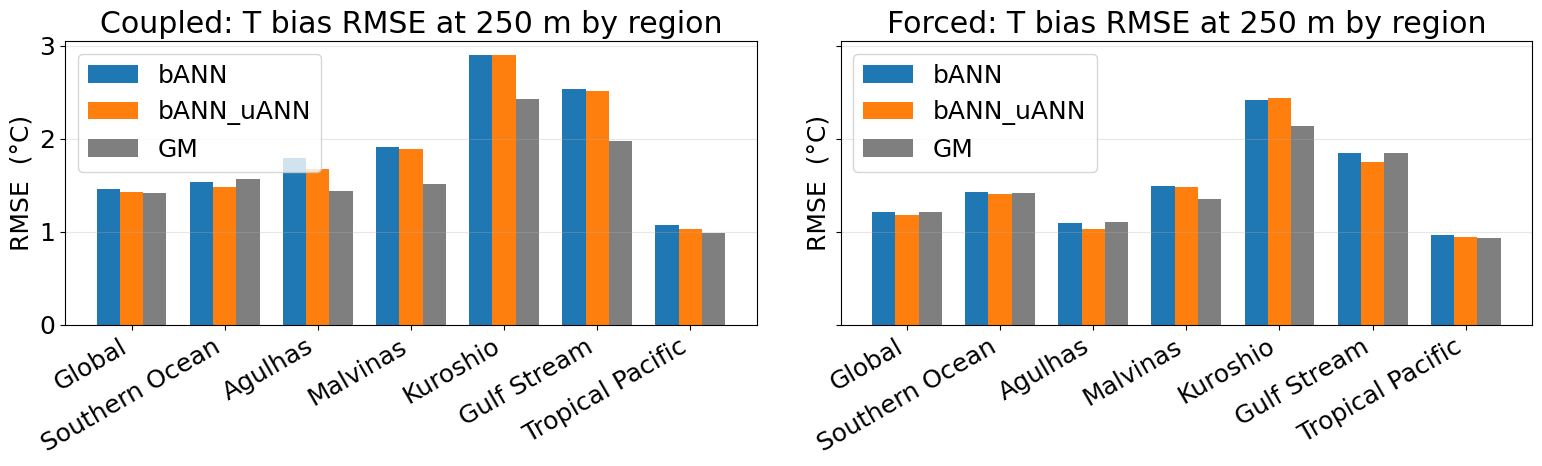

In [18]:
def region_t_rmse(exp, region, target_depth=TARGET_DEPTH):
    """Area-weighted RMSE of thetao_bias at ~target_depth over `region` [degC]."""
    bias = exp.thetao().thetao_bias.sel(z_l=target_depth, method='nearest')
    m = region_mask(exp, region) & np.isfinite(bias)
    w = exp.area.where(m)
    return float(np.sqrt((w * bias ** 2).sum() / w.sum()))


# RMSE table: rows = regions, columns = experiments.
rmse_t250 = pd.DataFrame(
    {name: [region_t_rmse(exps[name], r) for r in region_names]
     for name in exp_names},
    index=region_names,
)
print(f'Area-weighted T bias RMSE at ~{depth_used:.0f} m (degC):')
display(rmse_t250.round(3))

# --- Grouped bar charts: one panel per regime, groups = regions, bars = experiments ---
x = np.arange(len(region_names))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, names, regime in zip(axes,
                             [coupled_names, forced_names],
                             ['Coupled', 'Forced']):
    for k, name in enumerate(names):
        vals = rmse_t250[name].values
        lbl = LABELS[name]
        ax.bar(x + (k - 1) * width, vals, width,
               label=lbl, color=bar_colors.get(lbl, None))
    ax.set_title(f'{regime}: T bias RMSE at 250 m by region')
    ax.set_xticks(x)
    ax.set_xticklabels(region_names, rotation=30, ha='right')
    ax.set_ylabel('RMSE  (\u00b0C)')
    ax.grid(axis='y', alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# 7. Salinity bias at 250 m and regions

The analysis regions overlaid on the salinity bias (model $-$ WOA18) at the
model level nearest 250 m, for the GM coupled control.

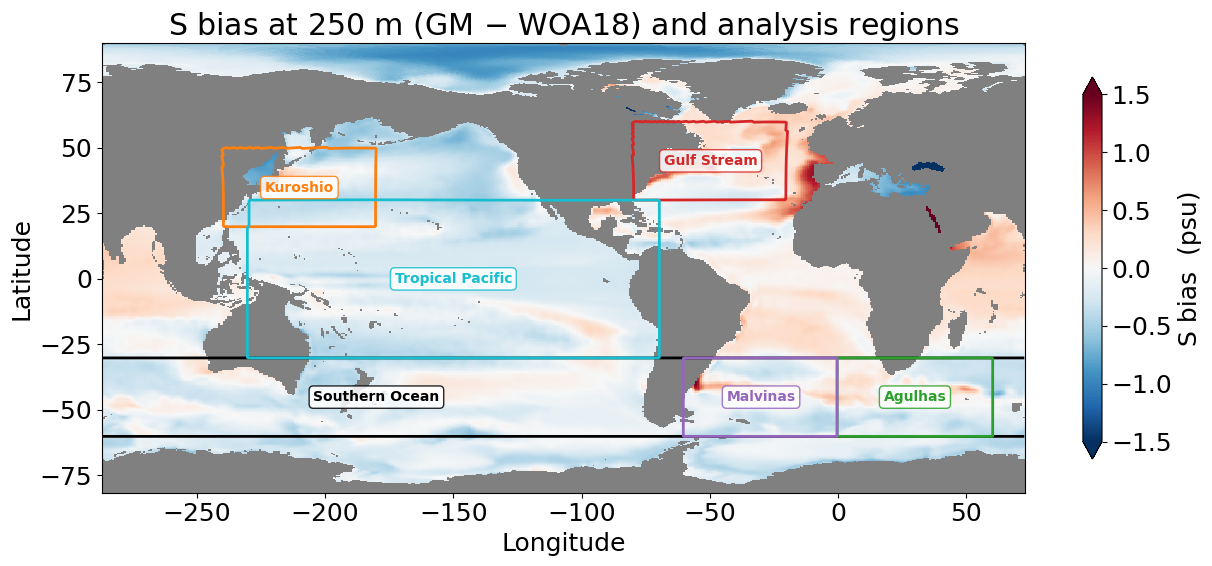

In [19]:
# Salinity bias (model - WOA18) at ~250 m for the GM coupled control ('CTRL'),
# with every analysis region outlined. 'Global' covers the whole domain and is not drawn.
exp = exps['CTRL']

s_bias = exp.so().so_bias.sel(z_l=TARGET_DEPTH, method='nearest')   # (yh, xh), psu
depth_used = float(s_bias.z_l)

# pcolormesh needs finite X/Y; fill NaN land points in the coords (as in biases.ipynb).
ydim, xdim = exp.grd.geolon.dims
lon = exp.grd.geolon.ffill(xdim).bfill(xdim).ffill(ydim).bfill(ydim).values
lat = exp.grd.geolat.ffill(ydim).bfill(ydim).ffill(xdim).bfill(xdim).values

fig, ax = plt.subplots(figsize=(13, 6))
ax.set_facecolor('gray')
norm = mpl.colors.Normalize(vmin=-1.5, vmax=1.5)
pc = ax.pcolormesh(lon, lat, np.ma.masked_invalid(s_bias.values),
                   cmap='RdBu_r', norm=norm, shading='auto')
cb = fig.colorbar(pc, ax=ax, shrink=0.85, extend='both')
cb.set_label('S bias  (psu)')

# Outline each region and label it at the box centre.
for name, box in REGIONS.items():
    if box is None:                       # 'Global' = whole domain
        continue
    m = region_mask(exp, name).values.astype(float)
    ax.contour(lon, lat, m, levels=[0.5],
               colors=REGION_COLORS[name], linewidths=2.0)
    s, n, w, e = box
    latc, lonc = 0.5 * (s + n), 0.5 * (w + e)
    d = (np.abs(exp.grd.geolat.values - latc)
         + np.abs((exp.grd.geolon.values % 360.0) - lonc))
    j, i = np.unravel_index(np.nanargmin(d), d.shape)
    ax.text(exp.grd.geolon.values[j, i], exp.grd.geolat.values[j, i], name,
            color=REGION_COLORS[name], fontsize=10, fontweight='bold',
            ha='center', va='center',
            bbox=dict(boxstyle='round', fc='white', ec=REGION_COLORS[name], alpha=0.85))

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'S bias at {depth_used:.0f} m (GM $-$ WOA18) and analysis regions')
plt.tight_layout()
plt.show()

# 8. Salinity bias RMSE at 250 m by region

Area-weighted root-mean-square salinity bias (model $-$ WOA18) at ~250 m over
each region for all six experiments, as a table and grouped bar charts
(coupled / forced).

Area-weighted salinity bias RMSE at ~250 m (psu):


,CTRL,coupled_bANN_1.0,coupled_bANN_1.0_uANN_1.0,forced_CTRL,forced_bANN_1.0,forced_bANN_1.0_uANN_1.0
Global,0.362,0.357,0.354,0.157,0.159,0.156
Southern Ocean,0.220,0.220,0.216,0.166,0.165,0.161
Agulhas,0.220,0.259,0.244,0.159,0.167,0.160
Malvinas,0.239,0.281,0.275,0.180,0.203,0.201
Kuroshio,0.340,0.333,0.315,0.194,0.216,0.215
Gulf Stream,0.315,0.316,0.330,0.256,0.270,0.265
Tropical Pacific,0.245,0.271,0.264,0.122,0.131,0.130


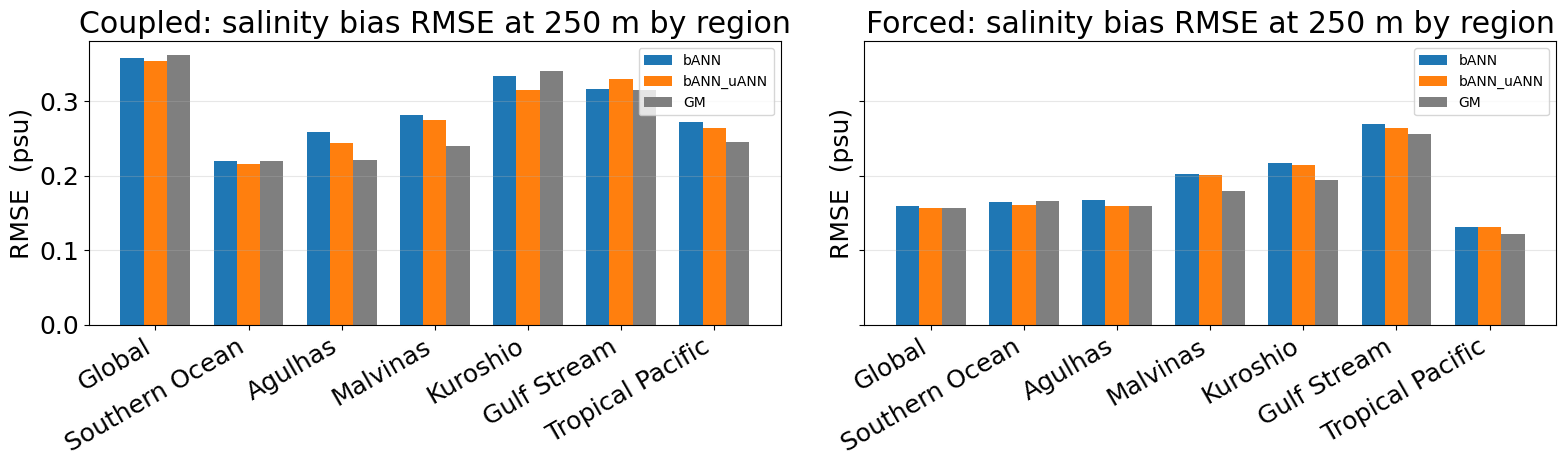

In [20]:
def region_s_rmse(exp, region, target_depth=TARGET_DEPTH):
    """Area-weighted RMSE of so_bias at ~target_depth over `region` [psu]."""
    bias = exp.so().so_bias.sel(z_l=target_depth, method='nearest')
    m = region_mask(exp, region) & np.isfinite(bias)
    w = exp.area.where(m)
    return float(np.sqrt((w * bias ** 2).sum() / w.sum()))


# RMSE table: rows = regions, columns = experiments.
rmse_s250 = pd.DataFrame(
    {name: [region_s_rmse(exps[name], r) for r in region_names]
     for name in exp_names},
    index=region_names,
)
print(f'Area-weighted salinity bias RMSE at ~{depth_used:.0f} m (psu):')
display(rmse_s250.round(3))

# --- Grouped bar charts: one panel per regime, groups = regions, bars = experiments ---
x = np.arange(len(region_names))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, names, regime in zip(axes,
                             [coupled_names, forced_names],
                             ['Coupled', 'Forced']):
    for k, name in enumerate(names):
        vals = rmse_s250[name].values
        lbl = LABELS[name]
        ax.bar(x + (k - 1) * width, vals, width,
               label=lbl, color=bar_colors.get(lbl, None))
    ax.set_title(f'{regime}: salinity bias RMSE at 250 m by region')
    ax.set_xticks(x)
    ax.set_xticklabels(region_names, rotation=30, ha='right')
    ax.set_ylabel('RMSE  (psu)')
    ax.grid(axis='y', alpha=0.3)
    ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()